In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

In [68]:
df = pd.read_csv("archive\AIML Dataset.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [69]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [71]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [72]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [73]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [74]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [75]:
df.shape

(6362620, 11)

In [76]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)

np.float64(0.13)

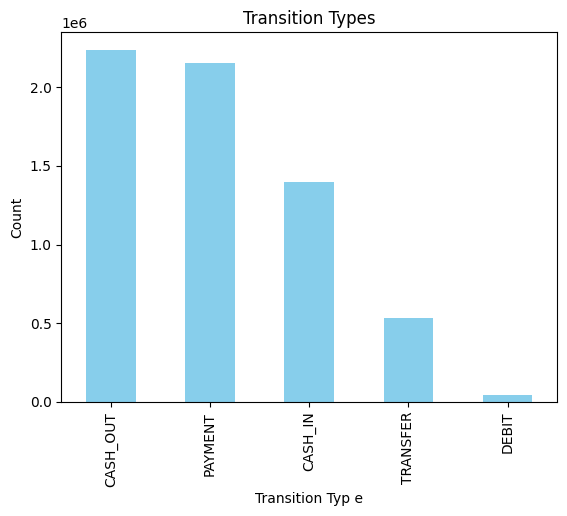

In [77]:
df["type"].value_counts().plot(kind="bar", title="Transition Types", color = "skyblue")
plt.xlabel("Transition Typ e")
plt.ylabel("Count")
plt.show()

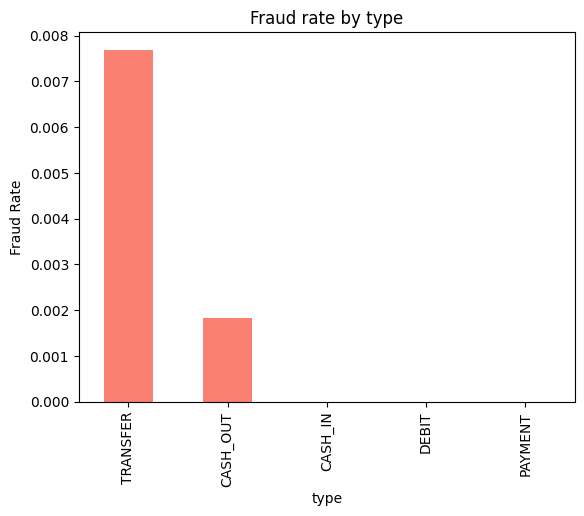

In [78]:
Fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
Fraud_by_type.plot(kind ="bar",title = "Fraud rate by type",color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [79]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

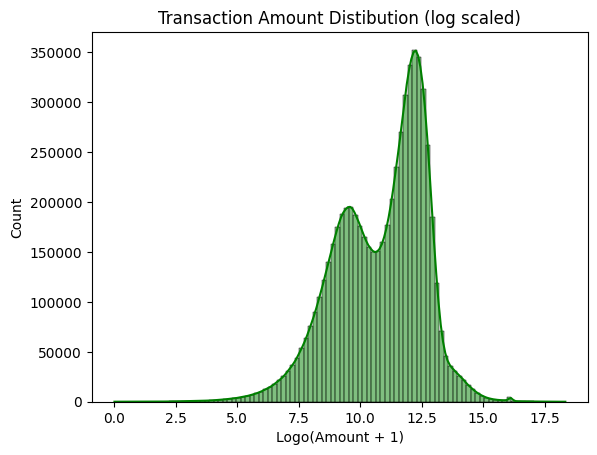

In [80]:
sns.histplot(np.log1p(df["amount"]), bins= 100, kde = True , color = "green")
plt.title("Transaction Amount Distibution (log scaled)")
plt.xlabel("Logo(Amount + 1)")
plt.show()

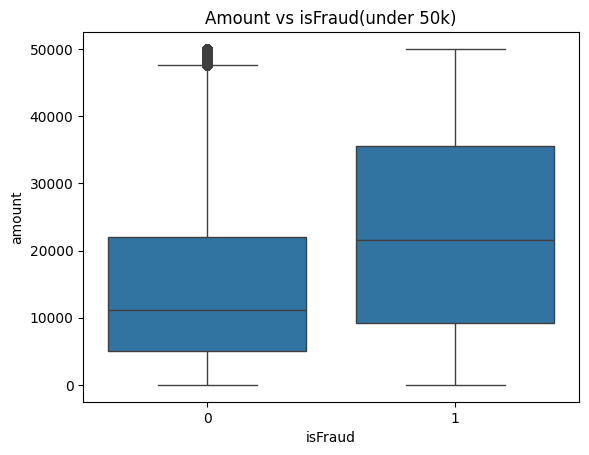

In [81]:
sns.boxplot(data= df[df["amount"]< 50000], x ="isFraud", y ="amount")
plt.title("Amount vs isFraud(under 50k)")
plt.show()

In [82]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [83]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [84]:
(df["balanceDiffOrig"]< 0).sum()

np.int64(1399253)

In [85]:
(df["balanceDiffDest"]< 0).sum()

np.int64(1238864)

In [86]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


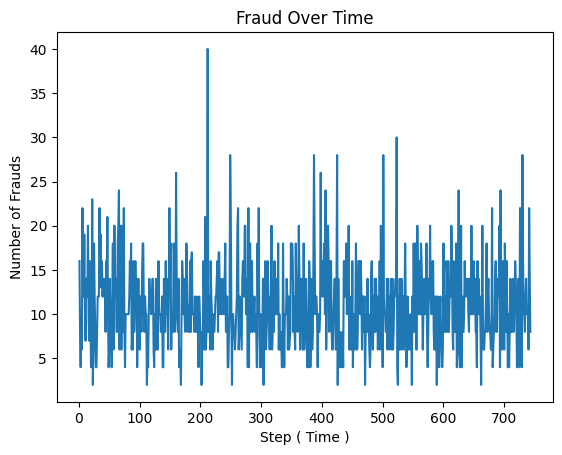

In [87]:
frauds_per_steps = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_steps.index, frauds_per_steps.values, label= "Frauds per Steps")
plt.xlabel("Step ( Time )")
plt.ylabel("Number of Frauds")
plt.title("Fraud Over Time")
plt.grid(False)
plt.show()

In [88]:
df.drop(columns="step", inplace= True)

In [89]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [90]:
top_senders = df["nameOrig"].value_counts().head(10)

In [91]:
top_senders 

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [92]:
top_receivers = df["nameDest"].value_counts().head(10)


In [93]:
top_receivers 


nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [94]:
fraud_users = df[df["isFraud"]== 1]["nameOrig"].value_counts().head(10)

In [95]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [96]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]


In [97]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

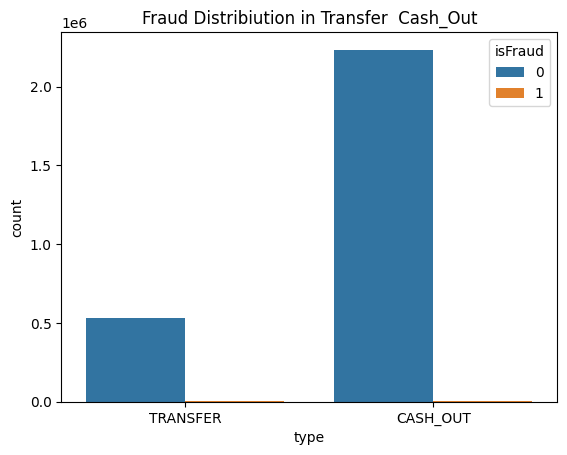

In [98]:
sns.countplot(data = fraud_types, x = "type", hue="isFraud" )
plt.title("Fraud Distribiution in Transfer  Cash_Out")
plt.show()

In [99]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [100]:
corr = df[["amount", "oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest", "isFraud"]].corr()

In [101]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


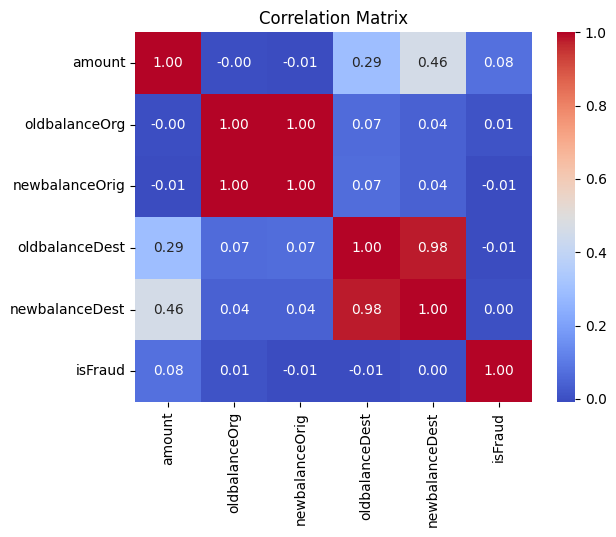

In [102]:
sns.heatmap(corr, annot= True, cmap ="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [103]:
zero_after_transfer = df[
    (df["oldbalanceOrg"]>0) &
    (df["newbalanceOrig"] == 0) & 
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [104]:
len(zero_after_transfer)

1188074

In [105]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [106]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [107]:
df_model = df.drop(["nameOrig","nameDest", "isFlaggedFraud"], axis = 1)

In [108]:
categorical = ["type"]
numeric = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balanceDiffOrig",   
    "balanceDiffDest",   
]

In [109]:
y = df_model["isFraud"]
X = df_model.drop("isFraud",axis = 1)

In [110]:
print("Feature shape   :", X.shape)
print("Target distribution:\n", y.value_counts())
print(f"\nFraud percentage : {round(y.mean()*100, 2)}%")

Feature shape   : (6362620, 8)
Target distribution:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage : 0.13%


In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [112]:
 
print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print(f"Fraud in train   : {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test    : {y_test.sum():,}  ({y_test.mean()*100:.2f}%)")
 

Training samples : 5,090,096
Testing  samples : 1,272,524
Fraud in train   : 6,570 (0.13%)
Fraud in test    : 1,643  (0.13%)


In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", StandardScaler(), numeric),
    ]
)
 
 

In [114]:
"""
## Model 1 — Logistic Regression
 
Logistic Regression is a linear classification model.
It predicts the probability that a transaction is fraud (between 0 and 1).
class_weight='balanced' compensates for the 0.13% fraud imbalance.
"""

"\n## Model 1 — Logistic Regression\n\nLogistic Regression is a linear classification model.\nIt predicts the probability that a transaction is fraud (between 0 and 1).\nclass_weight='balanced' compensates for the 0.13% fraud imbalance.\n"

In [115]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])
 
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

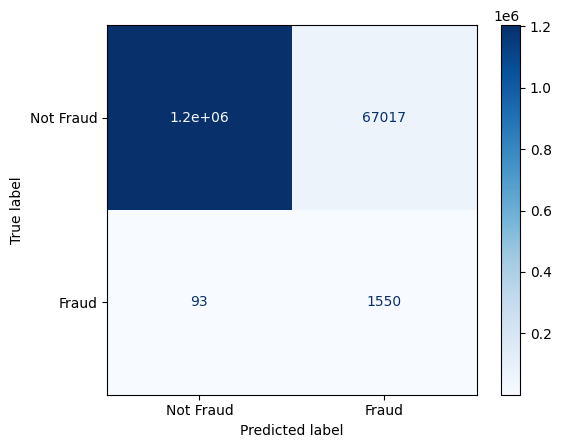

In [116]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                       display_labels=["Not Fraud", "Fraud"]).plot(cmap="Blues")

## Model 2 — Linear Regression
 
Linear Regression is technically a regression model (not a classifier).
It predicts a continuous number instead of 0 or 1.
To use it for classification, we:
  - Fit it to predict isFraud (0 or 1)
  - Round the output: if predicted value >= 0.5 → fraud (1), else → not fraud (0)
 
This is not ideal for binary classification but included for comparison.


In [117]:
lin_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
 
lin_pipeline.fit(X_train, y_train)
 
# Get continuous predictions then threshold at 0.5
y_pred_lin_raw = lin_pipeline.predict(X_test)
y_pred_lin = (y_pred_lin_raw >= 0.5).astype(int) 

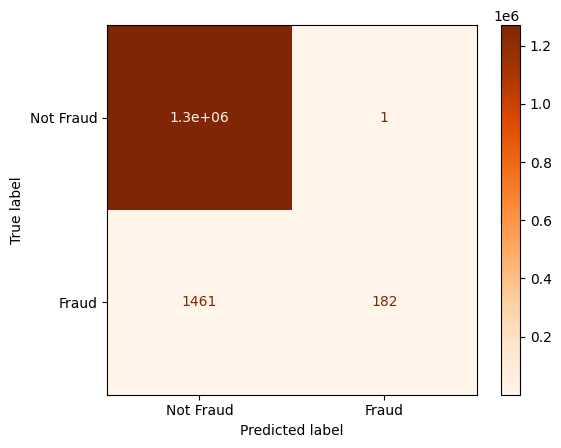

In [118]:
cm_lin = confusion_matrix(y_test, y_pred_lin)
ConfusionMatrixDisplay(confusion_matrix=cm_lin,
                       display_labels=["Not Fraud", "Fraud"]).plot(cmap="Oranges")


## Model 3 — K-Nearest Neighbors (KNN)
 
KNN classifies each transaction by finding its 5 most similar
transactions in the training set and taking a majority vote.
It makes no assumptions about data distribution.
 
NOTE: KNN is too slow on 6M rows, so we train on a 100k sample.
The test set remains the full 1.27M rows for fair evaluation.


In [119]:
SAMPLE_SIZE = 100_000
 
X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
 
print(f"KNN training on {SAMPLE_SIZE:,} sample rows")
print(f"Fraud in sample : {y_train_sample.sum()} ({y_train_sample.mean()*100:.2f}%)")
 
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1       # use all CPU cores
    ))
])
 
knn_pipeline.fit(X_train_sample, y_train_sample)
y_pred_knn = knn_pipeline.predict(X_test)

KNN training on 100,000 sample rows
Fraud in sample : 115 (0.11%)


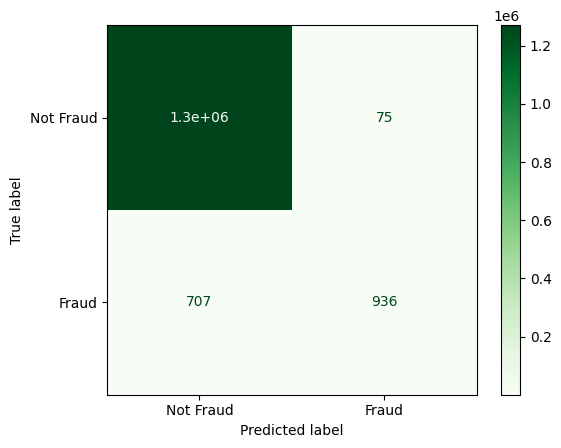

In [120]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                       display_labels=["Not Fraud", "Fraud"]).plot(cmap="Greens")

## Model 4 — Decision Tree
 
Decision Tree learns explicit if-then rules from the data.
max_depth=10 prevents the tree from becoming too complex (overfitting).
class_weight='balanced' handles the class imbalance.

In [ ]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        class_weight="balanced",
        random_state=42
    ))
])
 cm_dt = confusion_matrix(y_test, y_pred_dt)
 ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                        display_labels=["Not Fraud", "Fraud"]).plot(cmap="Purples")
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)


IndentationError: unexpected indent (1896617495.py, line 9)

: 

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                       display_labels=["Not Fraud", "Fraud"]).plot(cmap="Purples")
                       

In [ ]:
models_results = [
    ("Logistic Regression", y_pred_lr),
    ("Linear Regression",   y_pred_lin),
    ("KNN (k=5)",           y_pred_knn),
    ("Decision Tree",       y_pred_dt),
]
 
results = []
for name, y_pred in models_results:
    results.append({
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision" : round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        "Recall"    : round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        "F1-Score"  : round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
    })
 
results_df = pd.DataFrame(results).set_index("Model")

In [ ]:
print(f"★  Best Model by F1-Score: {results_df['F1-Score'].idxmax()}")
print(f"   F1-Score : {results_df['F1-Score'].max()}%")
print(f"   Precision: {results_df.loc[results_df['F1-Score'].idxmax(), 'Precision']}%")
print(f"   Recall   : {results_df.loc[results_df['F1-Score'].idxmax(), 'Recall']}%")

★  Best Model by F1-Score: KNN (k=5)
   F1-Score : 66.51%
   Precision: 94.71%
   Recall   : 51.25%


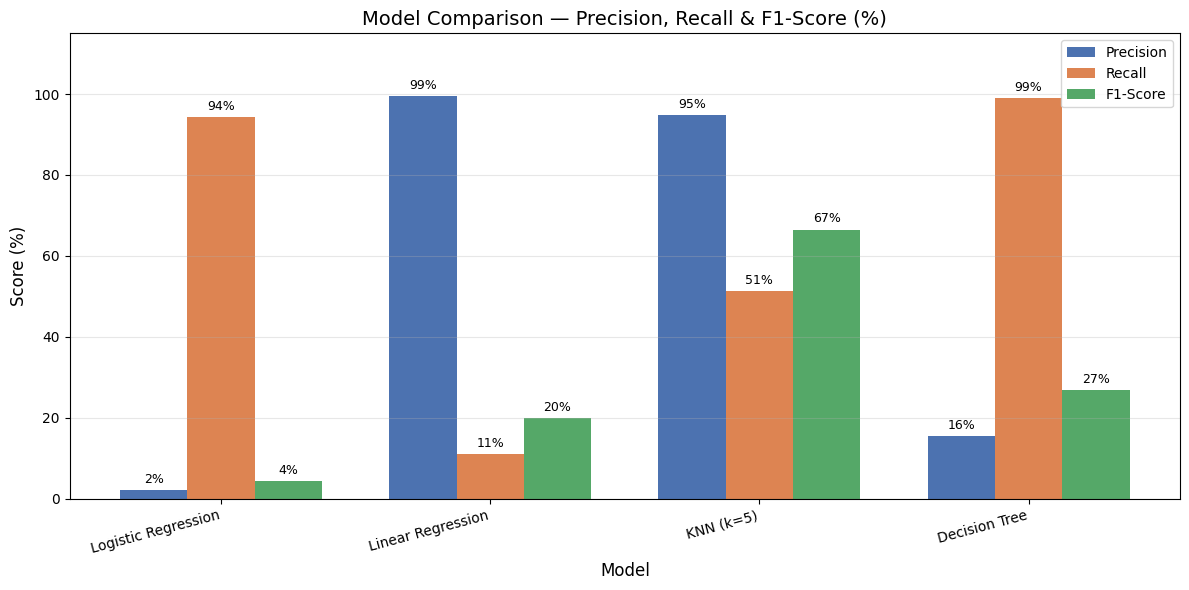

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
 
x = np.arange(len(results_df))
width = 0.25
 
bars1 = ax.bar(x - width, results_df["Precision"], width, label="Precision", color="#4C72B0")
bars2 = ax.bar(x,         results_df["Recall"],    width, label="Recall",    color="#DD8452")
bars3 = ax.bar(x + width, results_df["F1-Score"],  width, label="F1-Score",  color="#55A868")
 
# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.0f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
 
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Model Comparison — Precision, Recall & F1-Score (%)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha="right")
ax.set_ylim(0, 115)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

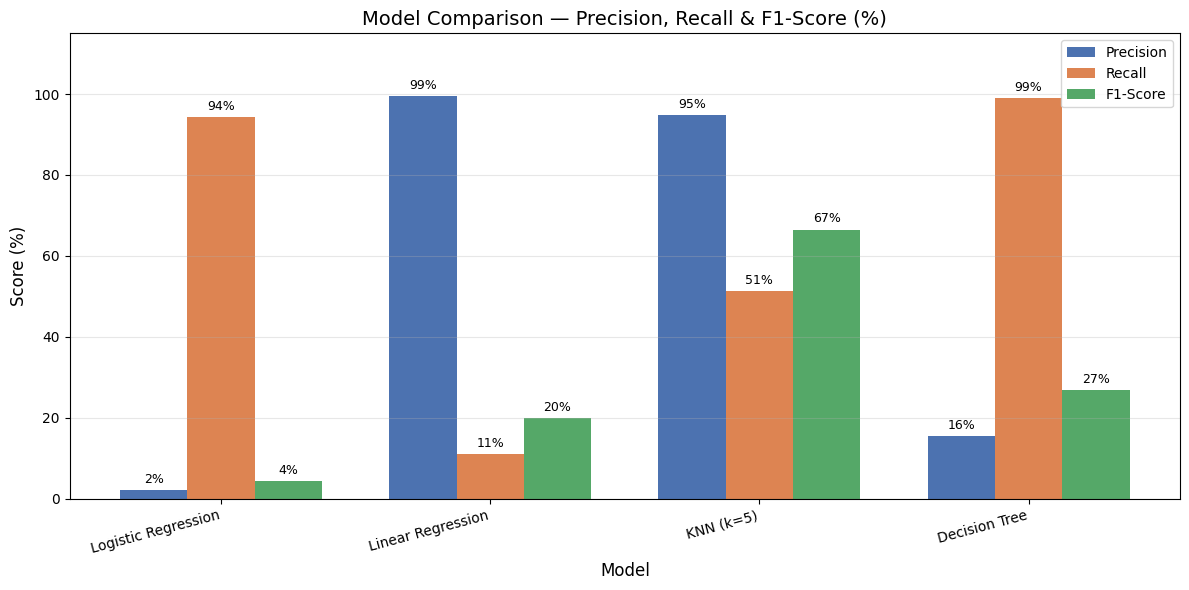

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
 
x = np.arange(len(results_df))
width = 0.25
 
bars1 = ax.bar(x - width, results_df["Precision"], width, label="Precision", color="#4C72B0")
bars2 = ax.bar(x,         results_df["Recall"],    width, label="Recall",    color="#DD8452")
bars3 = ax.bar(x + width, results_df["F1-Score"],  width, label="F1-Score",  color="#55A868")
 
# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.0f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
 
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Model Comparison — Precision, Recall & F1-Score (%)", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha="right")
ax.set_ylim(0, 115)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
 

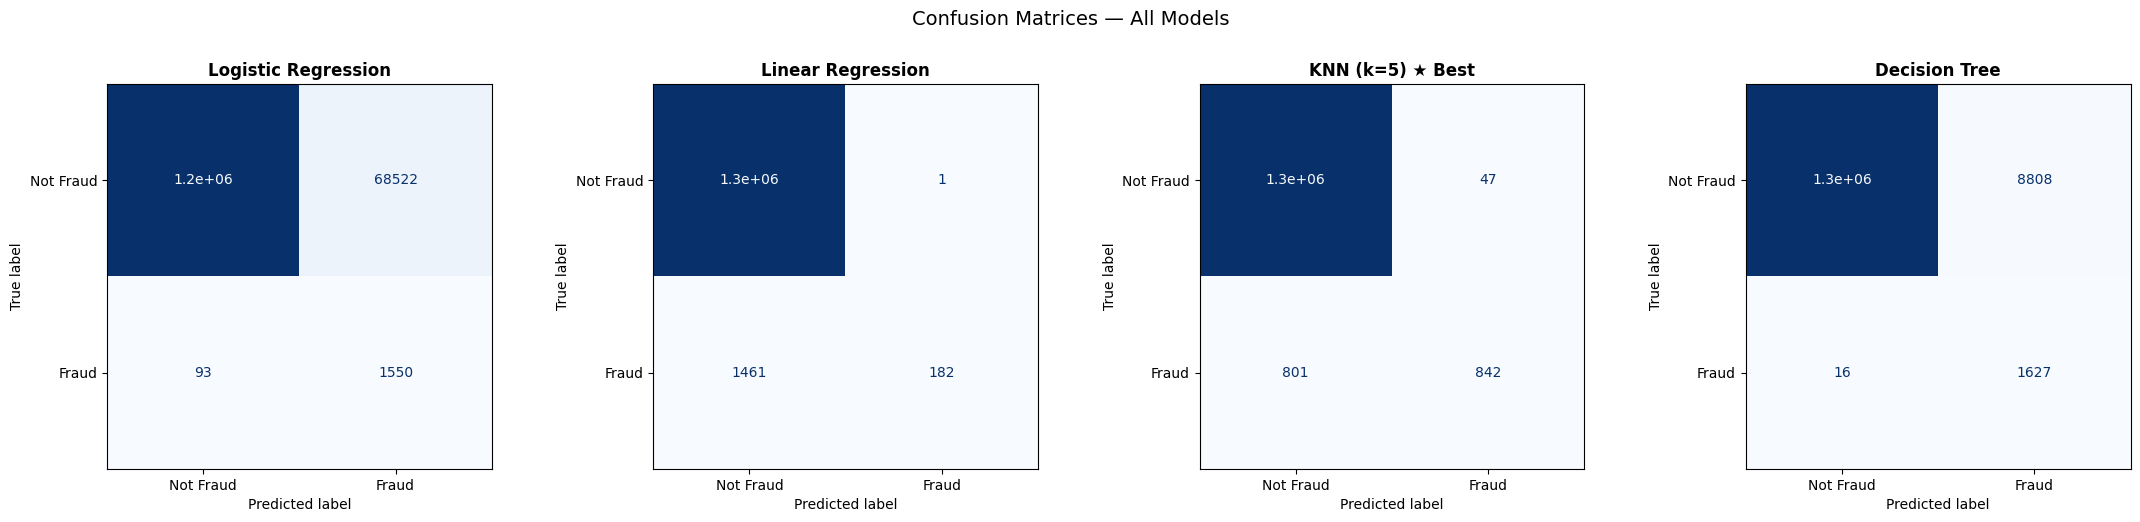

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
 
all_models = [
    ("Logistic Regression", y_pred_lr),
    ("Linear Regression",   y_pred_lin),
    ("KNN (k=5) ★ Best",    y_pred_knn),
    ("Decision Tree",       y_pred_dt),
]
 
for ax, (name, y_pred) in zip(axes, all_models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Fraud", "Fraud"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12, fontweight="bold")
 
plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import pandas as pd

# Load the saved model
model = joblib.load("frad_detection_pipeline.pkl")

#  Define test transactions 
transactions = [
    {
        "name": "Demo 1 — Classic Fraud (Account Drain)",
        "data": {
            "type": "TRANSFER",
            "amount": 181.00,
            "oldbalanceOrg": 181.00,
            "newbalanceOrig": 0.00,
            "oldbalanceDest": 0.00,
            "newbalanceDest": 0.00,
            "balanceDiffOrig": 181.00,
            "balanceDiffDest": 0.00,
        }
    },
    {
        "name": "Demo 2 — Large Suspicious Transfer",
        "data": {
            "type": "TRANSFER",
            "amount": 500000.00,
            "oldbalanceOrg": 500000.00,
            "newbalanceOrig": 0.00,
            "oldbalanceDest": 0.00,
            "newbalanceDest": 0.00,
            "balanceDiffOrig": 500000.00,
            "balanceDiffDest": 0.00,
        }
    },
    {
        "name": "Demo 3 — Normal Payment (Legitimate)",
        "data": {
            "type": "PAYMENT",
            "amount": 1000.00,
            "oldbalanceOrg": 10000.00,
            "newbalanceOrig": 9000.00,
            "oldbalanceDest": 5000.00,
            "newbalanceDest": 6000.00,
            "balanceDiffOrig": 1000.00,
            "balanceDiffDest": 1000.00,
        }
    },
    {
        "name": "Demo 4 — Cash Out Fraud",
        "data": {
            "type": "CASH_OUT",
            "amount": 229133.94,
            "oldbalanceOrg": 15325.00,
            "newbalanceOrig": 0.00,
            "oldbalanceDest": 0.00,
            "newbalanceDest": 0.00,
            "balanceDiffOrig": 15325.00,
            "balanceDiffDest": 0.00,
        }
    },
    {
        "name": "Demo 5 — Normal Transfer (Legitimate)",
        "data": {
            "type": "TRANSFER",
            "amount": 5000.00,
            "oldbalanceOrg": 20000.00,
            "newbalanceOrig": 15000.00,
            "oldbalanceDest": 3000.00,
            "newbalanceDest": 8000.00,
            "balanceDiffOrig": 5000.00,
            "balanceDiffDest": 5000.00,
        }
    },
]

# Run predictions 
print("=" * 60)
print("        FRAUD DETECTION SYSTEM — LIVE DEMO")
print("=" * 60)

for i, t in enumerate(transactions, 1):
    df_input = pd.DataFrame([t["data"]])
    prediction = model.predict(df_input)[0]
    result = "🚨 FRAUD DETECTED" if prediction == 1 else "✅ LEGITIMATE"
    
    print(f"\nTransaction {i}: {t['name']}")
    print(f"  Type    : {t['data']['type']}")
    print(f"  Amount  : ${t['data']['amount']:,.2f}")
    print(f"  Result  : {result}")
    print("-" * 60)

        FRAUD DETECTION SYSTEM — LIVE DEMO

Transaction 1: Demo 1 — Classic Fraud (Account Drain)
  Type    : TRANSFER
  Amount  : $181.00
  Result  : 🚨 FRAUD DETECTED
------------------------------------------------------------

Transaction 2: Demo 2 — Large Suspicious Transfer
  Type    : TRANSFER
  Amount  : $500,000.00
  Result  : 🚨 FRAUD DETECTED
------------------------------------------------------------

Transaction 3: Demo 3 — Normal Payment (Legitimate)
  Type    : PAYMENT
  Amount  : $1,000.00
  Result  : ✅ LEGITIMATE
------------------------------------------------------------

Transaction 4: Demo 4 — Cash Out Fraud
  Type    : CASH_OUT
  Amount  : $229,133.94
  Result  : ✅ LEGITIMATE
------------------------------------------------------------

Transaction 5: Demo 5 — Normal Transfer (Legitimate)
  Type    : TRANSFER
  Amount  : $5,000.00
  Result  : ✅ LEGITIMATE
------------------------------------------------------------
